# 🚀 Week 5 — Model Deployment

## Task 10: Deploy Your Model as a Live Web App

In this task, we will prepare the best-performing machine learning model from the previous tasks, save it using Joblib, and use it in a Streamlit web application.

## 1. Load the Dataset

We will use the Titanic dataset from the previous task to train and prepare the Random Forest model for deployment.

In [3]:
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

## 2. Load and Prepare the Titanic Dataset

We will load the Titanic dataset, handle missing values, remove unnecessary columns, and prepare the data for model training.

In [4]:
df = pd.read_csv("train.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


##  Check Missing Values

Before training the model, we will check the dataset for any missing values.

In [5]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [6]:
print("Column Names:")
print(df.columns.tolist())

Column Names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


##  Prepare Features and Target

We will separate the input features (`X`) from the target variable (`y`) before training the machine learning model.

In [7]:
# Separate features and target
X = df.drop("Survived", axis=1)
y = df["Survived"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (891, 11)
Target shape: (891,)


##  Split the Dataset

We will split the dataset into training and testing sets. The training data will be used to train the model, while the testing data will be used to evaluate its performance.

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 712
Testing samples: 179


In [9]:
# Check missing values in training data
print("Missing values in training data:")
print(X_train.isnull().sum())

Missing values in training data:
PassengerId      0
Pclass           0
Name             0
Sex              0
Age            137
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          552
Embarked         2
dtype: int64


##  Preprocess the Data

We will fill missing numerical values with the median and missing categorical values with the most frequent value. Categorical features will then be converted into numerical form using OneHotEncoder.

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# Select numerical and categorical columns
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X_train.select_dtypes(include=["object"]).columns

# Numerical preprocessing
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


C:\Users\Talal\AppData\Local\Temp\ipykernel_5784\2679580030.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(include=["object"]).columns


##  Train the Logistic Regression Model

We will use Logistic Regression as the classification model. The preprocessing pipeline will be combined with the model so that all preprocessing is applied automatically during training.

In [11]:
from sklearn.linear_model import LogisticRegression

# Create the complete model pipeline
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

# Train the model
model.fit(X_train, y_train)

print("Model training completed successfully.")

Model training completed successfully.


c:\Users\Talal\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


##  Evaluate the Model

We will make predictions on the test data and evaluate the model using accuracy, precision, recall, and F1-score.

In [12]:
from sklearn.metrics import accuracy_score, classification_report

# Make predictions
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy:", accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Test Accuracy: 0.8212290502793296

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.88      0.86       110
           1       0.79      0.72      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.81       179
weighted avg       0.82      0.82      0.82       179



##  Confusion Matrix

The confusion matrix will help us understand how many passengers were correctly and incorrectly classified as survived or not survived.

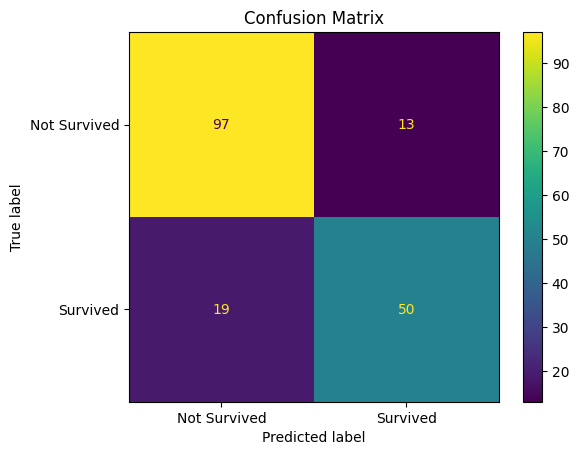

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Survived", "Survived"]
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

##  Save the Trained Model

We will save the trained model as a `.pkl` file so it can be loaded later in the Streamlit web application.

In [14]:
import joblib

# Save the trained model
joblib.dump(model, "titanic_model.pkl")

print("Model saved successfully as titanic_model.pkl")

Model saved successfully as titanic_model.pkl


##  Verify the Saved Model

We will load the saved model and make a sample prediction to confirm that the model was saved correctly and can be used for deployment.

In [15]:
# Load the saved model
loaded_model = joblib.load("titanic_model.pkl")

# Test prediction using the first test sample
sample_prediction = loaded_model.predict(X_test.iloc[[0]])

print("Sample Prediction:", sample_prediction[0])
print("Actual Value:", y_test.iloc[0])
print("Saved model loaded successfully.")

Sample Prediction: 0
Actual Value: 0
Saved model loaded successfully.


## Deployment Preparation

The trained model has been saved successfully. We will now create a Streamlit application that loads the saved model and allows users to enter passenger details for survival prediction.